# Dataset Inspection

In [1]:
import pandas as pd

In [7]:
obs_raw = pd.read_parquet("../data/interim/clean_obs.parquet")
obs_raw.head()

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,common_name,latitude,longitude,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
0,55574,http://www.inaturalist.org/observations/55574,research,cc-by,predator,Korthalsella complanata,species,Kaumahana,21.317598,-157.743287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Hawaii,Honolulu
1,55575,http://www.inaturalist.org/observations/55575,research,cc-by,prey,Syzygium sandwicense,species,ʻōhiʻa ha,21.317598,-157.743287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Hawaii,Honolulu
2,338604,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,Greater Roadrunner,25.557155,-103.453939,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
3,414645,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,Cape Wolf Snake,-15.836848,29.146428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
4,414707,http://www.inaturalist.org/observations/414707,research,cc-by,prey,Mochlus sundevallii,species,Sundevall's Writhing Skink,-15.836848,29.146428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7


In [8]:
animalia = obs_raw[obs_raw["kingdom_name"] == "Animalia"]

In [10]:
animalia.shape


(8221, 30)

In [11]:
animalia.info()

<class 'pandas.DataFrame'>
Index: 8221 entries, 2 to 10385
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   obs_id               8221 non-null   int64  
 1   obs_url              8221 non-null   str    
 2   quality_grade        8221 non-null   str    
 3   obs_license_code     8221 non-null   str    
 4   predator_prey_role   8068 non-null   str    
 5   scientific_name      8221 non-null   str    
 6   taxon_rank           8221 non-null   str    
 7   common_name          7668 non-null   str    
 8   latitude             8207 non-null   float64
 9   longitude            8207 non-null   float64
 10  positional_accuracy  6595 non-null   float64
 11  photo_count          8221 non-null   int64  
 12  kingdom_name         8221 non-null   str    
 13  phylum_name          8221 non-null   str    
 14  class_name           8202 non-null   str    
 15  order_name           8210 non-null   str    
 16  fam

# Validation

In [12]:
animalia.columns

Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'scientific_name', 'taxon_rank', 'common_name',
       'latitude', 'longitude', 'positional_accuracy', 'photo_count',
       'kingdom_name', 'phylum_name', 'class_name', 'order_name',
       'family_name', 'genus_name', 'species_name', 'subspecies_name',
       'subfamily_name', 'hybrid_name', 'complex_name', 'form_name',
       'subgenus_name', 'variety_name', 'tribe_name', 'country', 'state',
       'city'],
      dtype='str')

### taxon_rank distribution

In [17]:
# Taxon_rank types
un_taxon_ranks = animalia["taxon_rank"].value_counts()
# un_taxon_ranks[~(un_taxon_ranks.index == "species")]
un_taxon_ranks

taxon_rank
species       7052
subspecies     940
genus          107
hybrid          44
variety         26
complex         21
subgenus        11
tribe           11
subfamily        6
form             3
Name: count, dtype: int64

In [18]:
# count of records where taxon_rank is not equal to "species"
animalia[animalia["taxon_rank"] != "species"].shape[0]

1169

In [16]:
# Check if the df has requried taxon ranks
different_taxon_rank = [
    "complex",
    "subspecies",
    "subfamily",
    "genus",
    "hybrid",
    "form",
    "subgenus",
    "variety",
    "tribe",
]
not_species_ranks = animalia[animalia["taxon_rank"].isin(different_taxon_rank)][
    [
        "obs_id",
        "taxon_rank",
        "scientific_name",
        "kingdom_name",
        "phylum_name",
        "class_name",
        "order_name",
        "genus_name",
        "species_name",
    ]
]
not_species_ranks[not_species_ranks["taxon_rank"] == "tribe"]

,obs_id,taxon_rank,scientific_name,kingdom_name,phylum_name,class_name,order_name,genus_name,species_name
3295,155356270,tribe,Coriarachnini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
3444,164717774,tribe,Misumenini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
3478,166530832,tribe,Syrphini,Animalia,Arthropoda,Insecta,Diptera,NaN,NaN
6168,258151521,tribe,Misumenini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
6247,261666243,tribe,Aspidiotini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
6341,264989597,tribe,Aspidiotini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
6377,266453070,tribe,Aspidiotini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
6709,285504635,tribe,Misumenini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
7547,312197095,tribe,Macrosiphini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
7591,313706305,tribe,Aphidiini,Animalia,Arthropoda,Insecta,Hymenoptera,NaN,NaN


In [19]:
not_species_ranks.info()

<class 'pandas.DataFrame'>
Index: 1169 entries, 7 to 10381
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   obs_id           1169 non-null   int64
 1   taxon_rank       1169 non-null   str  
 2   scientific_name  1169 non-null   str  
 3   kingdom_name     1169 non-null   str  
 4   phylum_name      1169 non-null   str  
 5   class_name       1168 non-null   str  
 6   order_name       1168 non-null   str  
 7   genus_name       107 non-null    str  
 8   species_name     969 non-null    str  
dtypes: int64(1), str(8)
memory usage: 188.2 KB


In [20]:
animalia.columns

Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'scientific_name', 'taxon_rank', 'common_name',
       'latitude', 'longitude', 'positional_accuracy', 'photo_count',
       'kingdom_name', 'phylum_name', 'class_name', 'order_name',
       'family_name', 'genus_name', 'species_name', 'subspecies_name',
       'subfamily_name', 'hybrid_name', 'complex_name', 'form_name',
       'subgenus_name', 'variety_name', 'tribe_name', 'country', 'state',
       'city'],
      dtype='str')

In [22]:
animalia[
    [
        "obs_id",
        "scientific_name",
        "taxon_rank",
        "kingdom_name",
        "phylum_name",
        "class_name",
        "order_name",
        "family_name",
        "genus_name",
        "species_name",
        "subspecies_name",
        "subfamily_name",
        "hybrid_name",
        "complex_name",
        "form_name",
        "subgenus_name",
        "variety_name",
        "tribe_name",
    ]
].info()

<class 'pandas.DataFrame'>
Index: 8221 entries, 2 to 10385
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   obs_id           8221 non-null   int64
 1   scientific_name  8221 non-null   str  
 2   taxon_rank       8221 non-null   str  
 3   kingdom_name     8221 non-null   str  
 4   phylum_name      8221 non-null   str  
 5   class_name       8202 non-null   str  
 6   order_name       8210 non-null   str  
 7   family_name      8220 non-null   str  
 8   genus_name       107 non-null    str  
 9   species_name     8021 non-null   str  
 10  subspecies_name  940 non-null    str  
 11  subfamily_name   6 non-null      str  
 12  hybrid_name      44 non-null     str  
 13  complex_name     21 non-null     str  
 14  form_name        3 non-null      str  
 15  subgenus_name    11 non-null     str  
 16  variety_name     26 non-null     str  
 17  tribe_name       11 non-null     str  
dtypes: int64(1), str(17)
me

### Any unlicensed observations

In [23]:
# Check if there is any licensed images in the dataset
obs_license_distribution = animalia["obs_license_code"].value_counts().reset_index()
obs_license_distribution

,obs_license_code,count
0,cc-by-nc,5076
1,cc-by,2506
2,cc0,375
3,cc-by-nc-nd,129
4,cc-by-nc-sa,98
5,cc-by-sa,35
6,cc-by-nd,2


In [24]:
obs_license_distribution["obs_license_code"].unique()

<ArrowStringArray>
[   'cc-by-nc',       'cc-by',         'cc0', 'cc-by-nc-nd', 'cc-by-nc-sa',
    'cc-by-sa',    'cc-by-nd']
Length: 7, dtype: str

In [25]:
supported_licenses = [
    "cc-by-nc",
    "cc-by-sa",
    "cc-by-nd",
    "cc-by",
    "cc-by-nc",
    "cc-by-nc-sa",
    "cc-by-nc-nd",
    "cc0",
]
unsupported_licenses_count = animalia.loc[
    ~animalia["obs_license_code"].isin(supported_licenses), "obs_license_code"
].count()
print(f"Unsupported licenses count: {unsupported_licenses_count}")

Unsupported licenses count: 0


### Quality grade 

In [26]:
# Do we have any quality grades other than research grade
animalia["quality_grade"].unique()

<ArrowStringArray>
['research']
Length: 1, dtype: str

# Characterization Questions

## photo count distribution

In [29]:
# Number of images in the dataset
animalia.groupby("obs_id")["photo_count"].sum()

obs_id
338604        4
414645        2
414707        1
420386        1
424251        2
             ..
402861887     3
402870238     8
402894441    12
402961424     1
402961544     1
Name: photo_count, Length: 8221, dtype: int64

In [30]:
photo_dist = (
    animalia["photo_count"]
    .describe()
    .to_frame(name="photo_count")
    .rename_axis("statistic")
    .reset_index()
)
photo_dist

,statistic,photo_count
0,count,8221.000000
1,mean,2.974942
2,std,2.915660
3,min,1.000000
4,25%,1.000000
5,50%,2.000000
6,75%,4.000000
7,max,33.000000


In [31]:
photo_dist[photo_dist["statistic"] == "count"]

,statistic,photo_count
0,count,8221.0


In [33]:
animalia["photo_count"].sum()

np.int64(24457)

In [35]:
dist_val = animalia["photo_count"].value_counts().sort_index().reset_index()
dist_val.columns = ["photos_per_observation", "observation_count"]
dist_val

,photos_per_observation,observation_count
0,1,3077
1,2,1787
2,3,1184
3,4,748
4,5,436
5,6,259
6,7,194
7,8,137
8,9,88
9,10,77


In [37]:
photo_count_summary = pd.Series(
    {
        "1": dist_val.loc[
            dist_val["photos_per_observation"] == 1, "observation_count"
        ].sum(),
        "2": dist_val.loc[
            dist_val["photos_per_observation"] == 2, "observation_count"
        ].sum(),
        "3+": dist_val.loc[
            dist_val["photos_per_observation"] >= 3, "observation_count"
        ].sum(),
    }
)

print(photo_count_summary)

1     3077
2     1787
3+    3357
dtype: int64


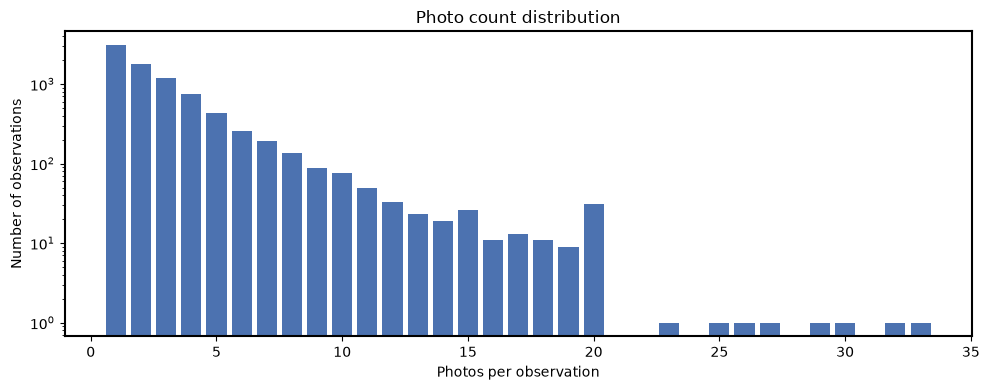

In [39]:
# Distribution of photo count per observation
import matplotlib.pyplot as plt

photo_counts = animalia["photo_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(photo_counts.index, photo_counts.values, color="#4C72B0")

ax.set_xlabel("Photos per observation")
ax.set_ylabel("Number of observations")
ax.set_title("Photo count distribution")
ax.set_yscale("log")

# Show all four borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


In [40]:
print(f"Total images: {animalia['photo_count'].sum()}")


Total images: 24457


In [41]:
animalia["photo_count"].describe()

count    8221.000000
mean        2.974942
std         2.915660
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        33.000000
Name: photo_count, dtype: float64

## Taxonomic composition

In [42]:
animalia.head()

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,common_name,latitude,longitude,...,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,country,state,city
2,338604,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,Greater Roadrunner,25.557155,-103.453939,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mexico,Coahuila,Torreón
3,414645,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,Cape Wolf Snake,-15.836848,29.146428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
4,414707,http://www.inaturalist.org/observations/414707,research,cc-by,prey,Mochlus sundevallii,species,Sundevall's Writhing Skink,-15.836848,29.146428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,Mashonaland West Province,Hurungwe 7
5,420386,http://www.inaturalist.org/observations/420386,research,cc-by-nc,NaN,Lampropeltis getula,species,Eastern Kingsnake,35.902263,-79.086335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,North Carolina,Orange
6,424251,http://www.inaturalist.org/observations/424251,research,cc-by-nc,prey,Hemidactylus turcicus,species,Mediterranean House Gecko,30.085165,-97.840715,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States,Texas,Hays


### Unique count in each ranks?

In [43]:
def unique_ranks(df):
    ranks = [
        "kingdom_name",
        "phylum_name",
        "class_name",
        "order_name",
        "family_name",
        "genus_name",
        "species_name",
    ]

    for rank in ranks:
        print(f"Unique {rank.replace('_name', '').capitalize()}: {df[rank].nunique()}")


unique_ranks(animalia)

Unique Kingdom: 1
Unique Phylum: 9
Unique Class: 29
Unique Order: 148
Unique Family: 629
Unique Genus: 71
Unique Species: 3073


### What percentage of observations belong to each major class/order/family?

In [44]:
def percentage_obs_ranks(df, rank_name, count=None):
    rank = (
        df[rank_name]
        .value_counts()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    rank["percentage"] = round((rank["count"] / df.shape[0]) * 100, 2)
    display(rank.head(count) if count is not None else rank)


In [45]:
percentage_obs_ranks(animalia, "phylum_name", 5)

,phylum_name,count,percentage
0,Chordata,4378,53.25
1,Arthropoda,3667,44.61
2,Mollusca,84,1.02
3,Echinodermata,59,0.72
4,Onychophora,11,0.13


In [46]:
percentage_obs_ranks(animalia, "class_name", 5)

,class_name,count,percentage
0,Insecta,2807,34.14
1,Aves,2803,34.10
2,Arachnida,732,8.90
3,Mammalia,572,6.96
4,Reptilia,535,6.51


In [48]:
percentage_obs_ranks(animalia, "order_name", 5)

,order_name,count,percentage
0,Passeriformes,977,11.88
1,Lepidoptera,842,10.24
2,Hymenoptera,791,9.62
3,Araneae,565,6.87
4,Squamata,451,5.49


In [49]:
percentage_obs_ranks(animalia, "family_name", 5)

,family_name,count,percentage
0,Apidae,393,4.78
1,Laridae,236,2.87
2,Accipitridae,228,2.77
3,Ardeidae,228,2.77
4,Nymphalidae,189,2.30


In [50]:
percentage_obs_ranks(animalia, "genus_name", 5)

,genus_name,count,percentage
0,Bombus,6,0.07
1,Lepomis,5,0.06
2,Agelenopsis,5,0.06
3,Lucilia,4,0.05
4,Oncorhynchus,4,0.05


In [51]:
percentage_obs_ranks(animalia, "species_name", 5)

,species_name,count,percentage
0,Apis mellifera,155,1.89
1,Aceria theospyri,115,1.40
2,Halcyon albiventris,108,1.31
3,Pandion haliaetus,93,1.13
4,Ardea herodias,87,1.06


In [52]:
class_counts = (
    animalia.dropna(subset=["class_name"])
    .groupby("class_name")["obs_id"]
    .nunique()
    .sort_values(ascending=False)
)

top_n = 12
class_plot = pd.concat(
    [
        class_counts.head(top_n),
        pd.Series({"Other": class_counts.iloc[top_n:].sum()}),
    ]
)


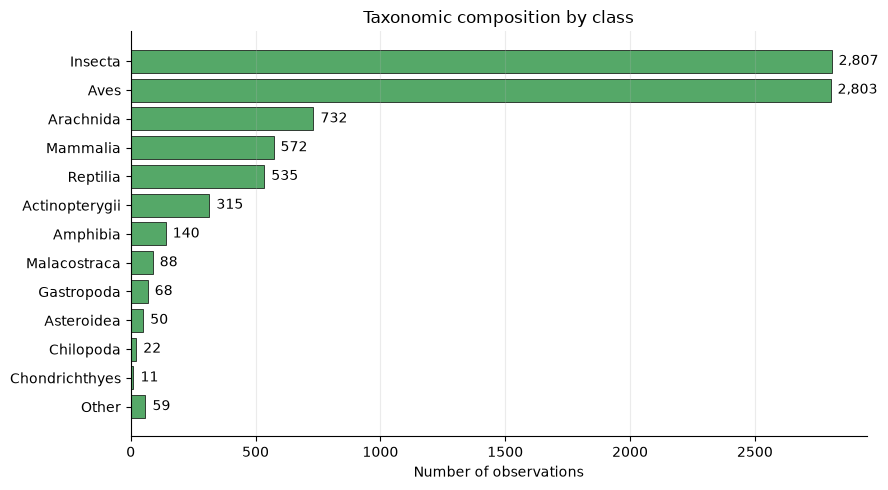

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    class_plot.index,
    class_plot.values,
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()
ax.set_xlabel("Number of observations")
ax.set_title("Taxonomic composition by class")

for bar, count in zip(bars, class_plot.values):
    ax.text(
        count + class_plot.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### What are the observation and photo count distribution under animalia for each phylum?

In [54]:
animalia["phylum_name"].unique()

<ArrowStringArray>
[       'Chordata',      'Arthropoda',   'Echinodermata',        'Mollusca',
        'Cnidaria',        'Nemertea',        'Annelida', 'Platyhelminthes',
     'Onychophora']
Length: 9, dtype: str

In [55]:
print(f"Observation distribution per phylum under animalia")
animalia.groupby("phylum_name").size().sort_values(ascending=False)

Observation distribution per phylum under animalia


phylum_name
Chordata           4378
Arthropoda         3667
Mollusca             84
Echinodermata        59
Onychophora          11
Platyhelminthes       8
Cnidaria              8
Annelida              5
Nemertea              1
dtype: int64

In [56]:
print(f"Photo count distribution per phylum under animalia")
animalia.groupby("phylum_name")["photo_count"].sum().sort_values(ascending=False)

Photo count distribution per phylum under animalia


phylum_name
Chordata           13404
Arthropoda         10622
Mollusca             241
Echinodermata         79
Onychophora           38
Cnidaria              30
Platyhelminthes       22
Annelida              17
Nemertea               4
Name: photo_count, dtype: int64

### What percentage of images belong to each major kingdom and phylum group?
Major = Kingdom, Phylym, Class

In [58]:
def per_img_rank(df, rank_name, count=None):
    rank = (
        df.groupby(rank_name)["photo_count"]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    display(rank.head(count) if count is not None else rank)

In [60]:
per_img_rank(animalia, "phylum_name")

,phylum_name,count
0,Chordata,13404
1,Arthropoda,10622
2,Mollusca,241
3,Echinodermata,79
4,Onychophora,38
5,Cnidaria,30
6,Platyhelminthes,22
7,Annelida,17
8,Nemertea,4


### How many species have:- 1 observation, 2 to 5 observations, 6 to 10, 11 to 50, 50

In [61]:
obs_per_species = (
    animalia.groupby("species_name")
    .size()
    .reset_index(name="observation_count")
    .sort_values(by="observation_count", ascending=False)
)

obs_per_species

,species_name,observation_count
230,Apis mellifera,155
28,Aceria theospyri,115
1244,Halcyon albiventris,108
2036,Pandion haliaetus,93
260,Ardea herodias,87
...,...,...
704,Cisticola chiniana,1
9,Acanthaspis obscura,1
16,Acanthorhynchus tenuirostris,1
3057,Zootermopsis angusticollis,1


In [62]:
one_obs = obs_per_species[obs_per_species["observation_count"] == 1][
    "species_name"
].nunique()
print(f"Number of species with only one observation: {one_obs}")

Number of species with only one observation: 1891


In [63]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 2)
    & (obs_per_species["observation_count"] <= 5)
]["species_name"].nunique()
print(f"Number of species with 2 to 5 observations: {one_obs}")

Number of species with 2 to 5 observations: 935


In [64]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 6)
    & (obs_per_species["observation_count"] <= 10)
]["species_name"].nunique()
print(f"Number of species with 6 to 10 observations: {one_obs}")

Number of species with 6 to 10 observations: 164


In [65]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 11)
    & (obs_per_species["observation_count"] <= 50)
]["species_name"].nunique()
print(f"Number of species with 11 to 50 observations: {one_obs}")

Number of species with 11 to 50 observations: 76


In [66]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 51)
    & (obs_per_species["observation_count"] <= 100)
]["species_name"].nunique()
print(f"Number of species with 51 to 100 observations: {one_obs}")

Number of species with 51 to 100 observations: 4


In [67]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 101)
    & (obs_per_species["observation_count"] <= 300)
]["species_name"].nunique()
print(f"Number of species with 101 to 300 observations: {one_obs}")

Number of species with 101 to 300 observations: 3


Observation per species distribution


In [68]:
import matplotlib.pyplot as plt

species_obs_counts = (
    animalia.dropna(subset=["species_name"])
    .groupby("species_name")["obs_id"]
    .nunique()
    .sort_values(ascending=False)
)

species_count_distribution = (
    species_obs_counts.value_counts()
    .sort_index()
    .rename_axis("observations_per_species")
    .reset_index(name="species_count")
)

print(f"Number of species: {species_obs_counts.shape[0]}")
print(f"Median observations per species: {species_obs_counts.median():.0f}")
print(f"Mean observations per species: {species_obs_counts.mean():.2f}")
print(f"Species with 1 observation: {(species_obs_counts == 1).sum()}")
print(f"Species with fewer than 5 observations: {(species_obs_counts < 5).sum()}")


Number of species: 3073
Median observations per species: 1
Mean observations per species: 2.61
Species with 1 observation: 1891
Species with fewer than 5 observations: 2740


In [69]:
display(species_count_distribution.head(10))


,observations_per_species,species_count
0,1,1891
1,2,503
2,3,230
3,4,116
4,5,86
5,6,47
6,7,45
7,8,26
8,9,26
9,10,20


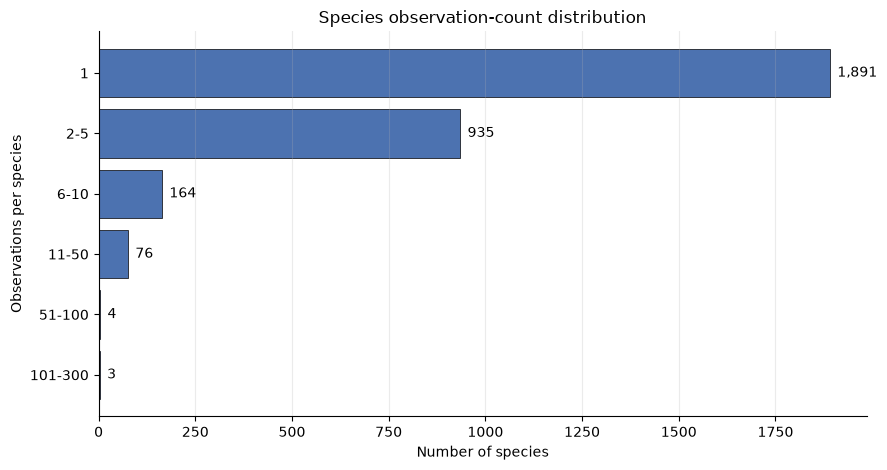

In [70]:
import matplotlib.pyplot as plt

bin_edges = [0, 1, 5, 10, 50, 100, 300]
bin_labels = ["1", "2-5", "6-10", "11-50", "51-100", "101-300"]

species_obs_bins = (
    pd.cut(
        species_obs_counts,
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
    )
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    species_obs_bins.index.astype(str),
    species_obs_bins.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel("Number of species")
ax.set_ylabel("Observations per species")
ax.set_title("Species observation-count distribution")

for bar, count in zip(bars, species_obs_bins.values):
    ax.text(
        count + species_obs_bins.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### What proportion of all images comes from the top 1%, 5%, and 10% most common species?

In [71]:
import numpy as np

# One row per species: observation count + image count
species_summary = (
    animalia.dropna(subset=["species_name"])
    .groupby("species_name")
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_count", "sum"),
    )
    .sort_values("observation_count", ascending=False)
)

total_images = species_summary["image_count"].sum()

for pct in [0.01, 0.05, 0.10, 0.30, 0.50]:
    n_species = max(1, int(np.ceil(len(species_summary) * pct)))
    top_images = species_summary.head(n_species)["image_count"].sum()
    image_share = top_images / total_images * 100

    print(
        f"Top {int(pct * 100)}% species "
        f"({n_species:,} species): {top_images:,} images "
        f"({image_share:.2f}% of all images)"
    )

Top 1% species (31 species): 4,031 images (16.82% of all images)
Top 5% species (154 species): 8,075 images (33.70% of all images)
Top 10% species (308 species): 10,784 images (45.00% of all images)
Top 30% species (922 species): 16,102 images (67.19% of all images)
Top 50% species (1,537 species): 18,842 images (78.63% of all images)


### What are the most represented species?

##  Predator versus prey composition

### How many observations are labeled predator and prey? What percentage is predator versus prey?

In [72]:
animalia["predator_prey_role"].unique()

<ArrowStringArray>
['predator', 'prey', nan]
Length: 3, dtype: str

In [73]:
pre_prey = animalia["predator_prey_role"].value_counts().reset_index()
pre_prey.columns = ["predator_prey_role", "count"]
pre_prey["Percentage"] = round((pre_prey["count"] / pre_prey["count"].sum()) * 100, 2)
pre_prey

,predator_prey_role,count,Percentage
0,predator,6269,77.7
1,prey,1799,22.3


### How many observations with no roles and which taxa rank govern it?

In [74]:
no_roles = animalia[animalia["predator_prey_role"].isna()]
no_roles.shape

(153, 30)

In [77]:
no_roles["phylum_name"].value_counts()

phylum_name
Chordata      86
Arthropoda    67
Name: count, dtype: int64

In [78]:
no_roles["class_name"].value_counts()

class_name
Insecta      65
Mammalia     40
Aves         23
Reptilia     22
Arachnida     2
Amphibia      1
Name: count, dtype: int64

### Are some taxa disproportionately represented as predator or prey?

In [79]:
role_col = "predator_prey_role"

role_df = animalia.dropna(subset=[role_col]).copy()

# Optional: keep only the two main roles if your column has other values
role_df = role_df[role_df[role_col].isin(["predator", "prey"])]

In [80]:
# 1. Are some taxa disproportionately represented as predator or prey?

taxa_role_summary = (
    role_df.groupby([role_col, "phylum_name"])
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_count", "sum"),
        species_count=("species_name", "nunique"),
    )
    .reset_index()
)


In [81]:
phylum_role_obs = taxa_role_summary.pivot(
    index="phylum_name",
    columns=role_col,
    values="observation_count",
).fillna(0)

phylum_role_obs["total"] = phylum_role_obs.sum(axis=1)
phylum_role_obs["predator_share"] = (
    phylum_role_obs.get("predator", 0) / phylum_role_obs["total"] * 100
)
phylum_role_obs["prey_share"] = (
    phylum_role_obs.get("prey", 0) / phylum_role_obs["total"] * 100
)

phylum_role_obs.sort_values("total", ascending=False)

predator_prey_role,predator,prey,total,predator_share,prey_share
phylum_name,,,,,
Chordata,3361.0,931.0,4292.0,78.308481,21.691519
Arthropoda,2828.0,772.0,3600.0,78.555556,21.444444
Mollusca,50.0,34.0,84.0,59.523810,40.476190
Echinodermata,3.0,56.0,59.0,5.084746,94.915254
Onychophora,9.0,2.0,11.0,81.818182,18.181818
Platyhelminthes,8.0,0.0,8.0,100.000000,0.000000
Cnidaria,7.0,1.0,8.0,87.500000,12.500000
Annelida,2.0,3.0,5.0,40.000000,60.000000
Nemertea,1.0,0.0,1.0,100.000000,0.000000


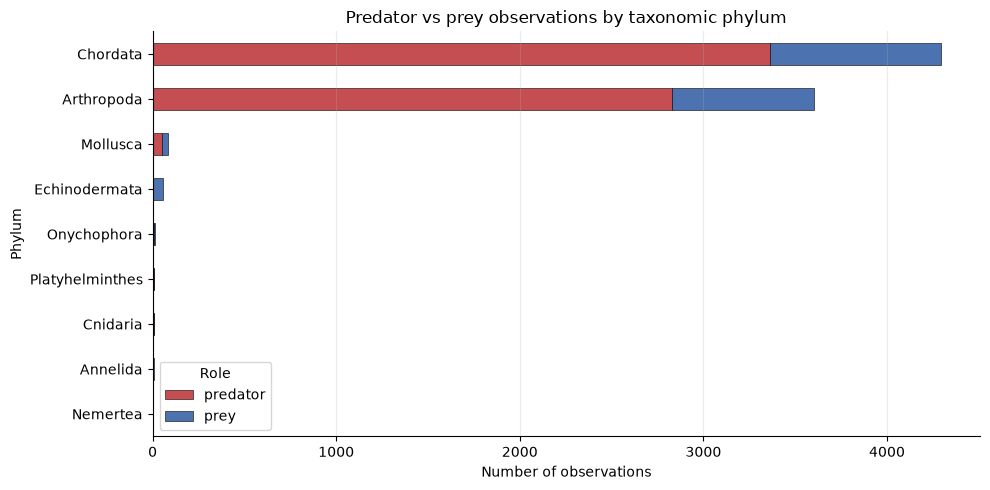

In [82]:
top_classes = phylum_role_obs.sort_values("total", ascending=False).head(12).index

plot_df = phylum_role_obs.loc[top_classes, ["predator", "prey"]]

fig, ax = plt.subplots(figsize=(10, 5))

plot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.4,
)

ax.invert_yaxis()
ax.set_xlabel("Number of observations")
ax.set_ylabel("Phylum")
ax.set_title("Predator vs prey observations by taxonomic phylum")
ax.legend(title="Role")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Is taxonomic diversity similar across the two roles?

In [83]:
taxonomic_diversity_by_role = role_df.groupby(role_col).agg(
    observations=("obs_id", "nunique"),
    images=("photo_count", "sum"),
    classes=("class_name", "nunique"),
    orders=("order_name", "nunique"),
    families=("family_name", "nunique"),
    genera=("genus_name", "nunique"),
    species=("species_name", "nunique"),
)

taxonomic_diversity_by_role

,observations,images,classes,orders,families,genera,species
predator_prey_role,,,,,,,
predator,6269,18994,19,107,440,51,2339
prey,1799,5198,26,114,389,26,977


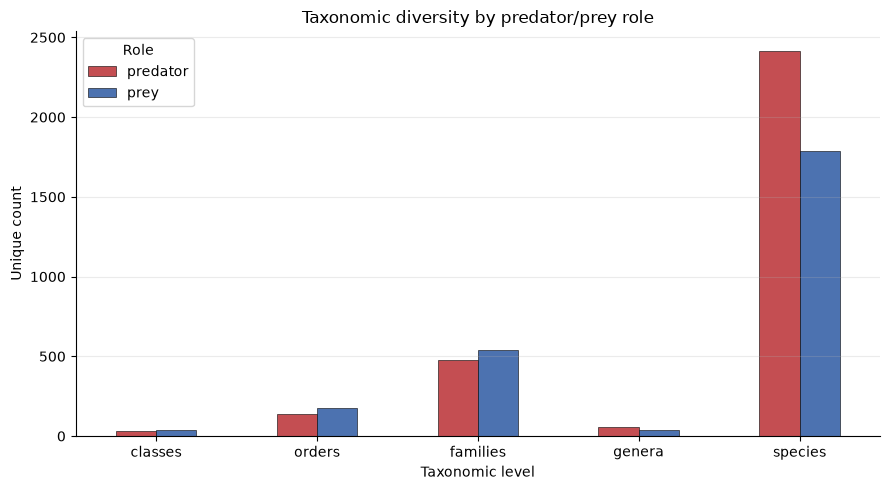

In [76]:
diversity_plot = taxonomic_diversity_by_role[
    ["classes", "orders", "families", "genera", "species"]
].T

fig, ax = plt.subplots(figsize=(9, 5))

diversity_plot.plot(
    kind="bar",
    ax=ax,
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.4,
)

ax.set_xlabel("Taxonomic level")
ax.set_ylabel("Unique count")
ax.set_title("Taxonomic diversity by predator/prey role")
ax.legend(title="Role")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Is image count balanced between predator and prey?

In [84]:
image_balance_by_role = role_df.groupby(role_col).agg(
    observations=("obs_id", "nunique"),
    images=("photo_count", "sum"),
    mean_images_per_observation=("photo_count", "mean"),
    median_images_per_observation=("photo_count", "median"),
)

image_balance_by_role["image_share_percent"] = (
    image_balance_by_role["images"] / image_balance_by_role["images"].sum() * 100
)

image_balance_by_role

,observations,images,mean_images_per_observation,median_images_per_observation,image_share_percent
predator_prey_role,,,,,
predator,6269,18994,3.029829,2.0,78.513558
prey,1799,5198,2.889383,2.0,21.486442


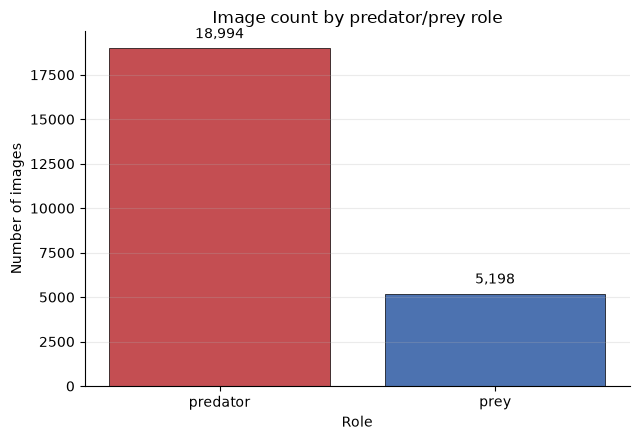

In [85]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

bars = ax.bar(
    image_balance_by_role.index,
    image_balance_by_role["images"],
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xlabel("Role")
ax.set_ylabel("Number of images")
ax.set_title("Image count by predator/prey role")

for bar, count in zip(bars, image_balance_by_role["images"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + image_balance_by_role["images"].max() * 0.02,
        f"{int(count):,}",
        ha="center",
        va="bottom",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Geographic coverage


### How many countries are represented?

In [86]:
country_dist = (
    animalia.groupby("country")
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)
country_dist

,country,count
111,United States,3830
92,South Africa,899
103,Thailand,443
117,Zimbabwe,356
15,Canada,287
...,...,...
107,Turkey,1
106,Trinidad and Tobago,1
112,Uruguay,1
113,Vanuatu,1


### What are the top 5 countries by observation count and their percentages?

In [87]:
country_dist["percentage"] = round(
    (country_dist["count"] / country_dist["count"].sum()) * 100, 2
)
country_dist.head()

,country,count,percentage
111,United States,3830,46.67
92,South Africa,899,10.95
103,Thailand,443,5.40
117,Zimbabwe,356,4.34
15,Canada,287,3.50


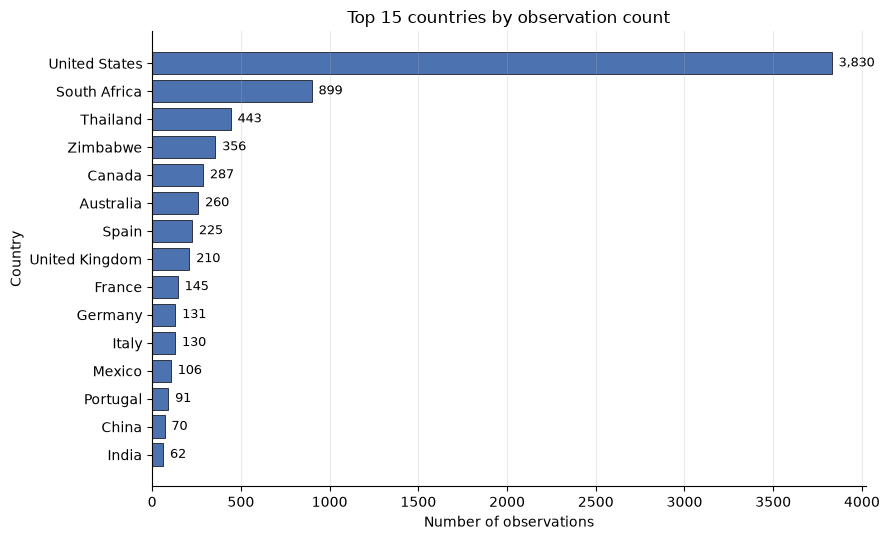

In [88]:
import matplotlib.pyplot as plt

top_n = 15

country_plot = country_dist.sort_values("count", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    country_plot["country"],
    country_plot["count"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel("Number of observations")
ax.set_ylabel("Country")
ax.set_title(f"Top {top_n} countries by observation count")

for bar, count in zip(bars, country_plot["count"]):
    ax.text(
        count + country_plot["count"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}",
        va="center",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### How geographically concentrated is the dataset?


In [89]:
country_col = "country"
obs_col = "obs_id"

In [90]:
# Geographic analysis dataframe

geo_df = animalia.copy()

geo_df[country_col] = (
    geo_df[country_col]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
)

usable_geo_df = geo_df.dropna(subset=[country_col])

In [91]:
# How geographically concentrated is the dataset?

country_dist = (
    usable_geo_df.groupby(country_col)
    .agg(
        observation_count=(obs_col, "nunique"),
        image_count=("photo_count", "sum"),
        species_count=("species_name", "nunique"),
        class_count=("class_name", "nunique"),
        order_count=("order_name", "nunique"),
    )
    .sort_values("observation_count", ascending=False)
    .reset_index()
)

total_geo_observations = country_dist["observation_count"].sum()

country_dist["observation_share_percent"] = (
    country_dist["observation_count"] / total_geo_observations * 100
)

country_dist["cumulative_share_percent"] = country_dist[
    "observation_share_percent"
].cumsum()

print(f"Countries represented: {country_dist.shape[0]:,}")
print(
    f"Top 1 country share: {country_dist.head(1)['observation_share_percent'].sum():.2f}%"
)
print(
    f"Top 5 countries share: {country_dist.head(5)['observation_share_percent'].sum():.2f}%"
)
print(
    f"Top 10 countries share: {country_dist.head(10)['observation_share_percent'].sum():.2f}%"
)

country_dist.head(15)

Countries represented: 118
Top 1 country share: 46.67%
Top 5 countries share: 70.85%
Top 10 countries share: 82.69%


,country,observation_count,image_count,species_count,class_count,order_count,observation_share_percent,cumulative_share_percent
0,United States,3830,10873,1175,27,114,46.667479,46.667479
1,South Africa,899,4714,410,11,53,10.954064,57.621543
2,Thailand,443,1064,305,11,41,5.397831,63.019374
3,Zimbabwe,356,719,202,8,35,4.337760,67.357134
4,Canada,287,707,163,12,43,3.497015,70.854149
5,Australia,260,730,167,11,50,3.168027,74.022176
6,Spain,225,533,152,10,35,2.741562,76.763738
7,United Kingdom,210,611,105,10,35,2.558791,79.322530
8,France,145,295,74,8,26,1.766784,81.089314
9,Germany,131,451,92,8,33,1.596198,82.685512


### How many observations lack usable geographic metadata?

In [92]:
missing_geo_summary = pd.Series(
    {
        "total_observations": geo_df[obs_col].nunique(),
        "observations_with_country": usable_geo_df[obs_col].nunique(),
        "observations_missing_country": geo_df[geo_df[country_col].isna()][
            obs_col
        ].nunique(),
        "percent_missing_country": (
            geo_df[geo_df[country_col].isna()][obs_col].nunique()
            / geo_df[obs_col].nunique()
            * 100
        ),
    }
)

missing_geo_summary

total_observations              8221.000000
observations_with_country       8207.000000
observations_missing_country      14.000000
percent_missing_country            0.170296
dtype: float64

### Does taxonomic richness vary by geographic region?

In [93]:
geo_richness = (
    usable_geo_df.groupby(country_col)
    .agg(
        observations=(obs_col, "nunique"),
        images=("photo_count", "sum"),
        classes=("class_name", "nunique"),
        orders=("order_name", "nunique"),
        families=("family_name", "nunique"),
        genera=("genus_name", "nunique"),
        species=("species_name", "nunique"),
    )
    .sort_values("species", ascending=False)
    .reset_index()
)

geo_richness["species_per_100_observations"] = (
    geo_richness["species"] / geo_richness["observations"] * 100
)

geo_richness.head(15)

,country,observations,images,classes,orders,families,genera,species,species_per_100_observations
0,United States,3830,10873,27,114,376,32,1175,30.678851
1,South Africa,899,4714,11,53,176,6,410,45.606229
2,Thailand,443,1064,11,41,107,0,305,68.848758
3,Zimbabwe,356,719,8,35,102,0,202,56.741573
4,Australia,260,730,11,50,107,3,167,64.230769
5,Canada,287,707,12,43,101,1,163,56.794425
6,Spain,225,533,10,35,91,2,152,67.555556
7,United Kingdom,210,611,10,35,68,1,105,50.000000
8,Germany,131,451,8,33,72,1,92,70.229008
9,Italy,130,284,9,30,61,2,81,62.307692


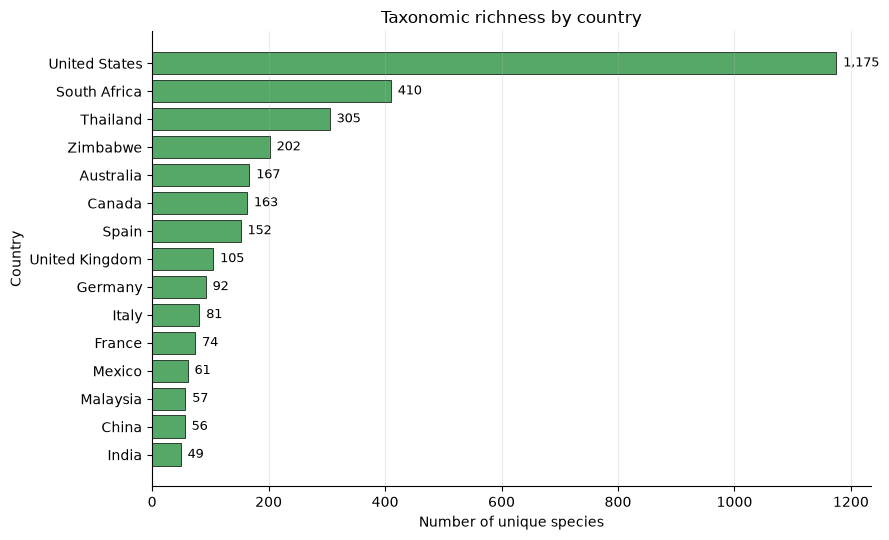

In [94]:
# Plot: species richness by country

richness_plot = geo_richness.sort_values("species", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    richness_plot[country_col],
    richness_plot["species"],
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()
ax.set_xlabel("Number of unique species")
ax.set_ylabel("Country")
ax.set_title("Taxonomic richness by country")

for bar, count in zip(bars, richness_plot["species"]):
    ax.text(
        count + richness_plot["species"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}",
        va="center",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Are certain species heavily tied to particular countries?

In [95]:
species_country = (
    usable_geo_df.dropna(subset=["species_name"])
    .groupby(["species_name", country_col])
    .agg(observation_count=(obs_col, "nunique"))
    .reset_index()
)


In [96]:
species_total = (
    species_country.groupby("species_name")["observation_count"]
    .sum()
    .rename("species_total_observations")
)


In [97]:
species_country = species_country.merge(
    species_total,
    on="species_name",
    how="left",
)


In [98]:
species_country["country_share_percent"] = (
    species_country["observation_count"]
    / species_country["species_total_observations"]
    * 100
)


In [99]:
country_tied_species = (
    species_country.sort_values(
        ["species_name", "country_share_percent", "observation_count"],
        ascending=[True, False, False],
    )
    .groupby("species_name")
    .head(1)
    .query("species_total_observations >= 5 and country_share_percent >= 80")
    .sort_values(
        ["country_share_percent", "species_total_observations"],
        ascending=False,
    )
)

print(
    "Species with at least 5 observations where >=80% of observations "
    "come from one country:",
    country_tied_species.shape[0],
)

country_tied_species.head(20)

Species with at least 5 observations where >=80% of observations come from one country: 200


,species_name,country,observation_count,species_total_observations,country_share_percent
43,Aceria theospyri,United States,115,115,100.0
1604,Halcyon albiventris,South Africa,108,108,100.0
2485,Omphalocera munroei,United States,86,86,100.0
1437,Evasterias troschelii,United States,43,43,100.0
148,Alligator mississippiensis,United States,38,38,100.0
1379,Erythemis simplicicollis,United States,38,38,100.0
1908,Larus glaucescens,United States,29,29,100.0
2903,Platycryptus undatus,United States,29,29,100.0
3569,Tetradactylus seps,South Africa,27,27,100.0
2815,Phoenicopterus roseus,France,24,24,100.0


###  Is the dataset overwhelmingly North American or broadly global?

In [100]:
north_america_countries = {
    "United States",
    "Canada",
    "Mexico",
    "Greenland",
    "Bermuda",
    "Saint Pierre and Miquelon",
}

country_dist["region_group"] = np.where(
    country_dist[country_col].isin(north_america_countries),
    "North America",
    "Outside North America",
)

region_summary = country_dist.groupby("region_group").agg(
    observations=("observation_count", "sum"),
    images=("image_count", "sum"),
    species=("species_count", "sum"),
    countries=(country_col, "nunique"),
)

region_summary["observation_share_percent"] = (
    region_summary["observations"] / region_summary["observations"].sum() * 100
)

region_summary

,observations,images,species,countries,observation_share_percent
region_group,,,,,
North America,4224,11921,1400,4,51.468259
Outside North America,3983,12450,2531,114,48.531741


## Long-tail and imbalance questions

In [101]:
# Species frequency summary

species_freq = (
    animalia.dropna(subset=["species_name"])
    .groupby("species_name")
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_count", "sum"),
    )
    .sort_values("observation_count", ascending=False)
)

total_species = species_freq.shape[0]
total_observations = species_freq["observation_count"].sum()
total_images = species_freq["image_count"].sum()

median_obs_per_species = species_freq["observation_count"].median()
pct_species_under_5_obs = (species_freq["observation_count"] < 5).mean() * 100
most_common_species_obs_share = (
    species_freq["observation_count"].max() / total_observations * 100
)

print(f"Number of species: {total_species:,}")
print(f"Median observations per species: {median_obs_per_species:.0f}")
print(f"Species with fewer than 5 observations: {pct_species_under_5_obs:.2f}%")
print(f"Most common species observation share: {most_common_species_obs_share:.2f}%")

species_freq.head(10)

Number of species: 3,073
Median observations per species: 1
Species with fewer than 5 observations: 89.16%
Most common species observation share: 1.93%


,observation_count,image_count
species_name,,
Apis mellifera,155,329
Aceria theospyri,115,233
Halcyon albiventris,108,462
Pandion haliaetus,93,274
Ardea herodias,87,345
Omphalocera munroei,86,148
Passer domesticus,83,229
Turdus migratorius,46,99
Sciurus carolinensis,45,93


### What is the Gini coefficient or another concentration statistic for species frequency?

In [102]:
# Gini coefficient for species observation frequency


def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if values.size == 0:
        return np.nan

    if np.any(values < 0):
        raise ValueError("Gini coefficient is not defined for negative values.")

    if values.sum() == 0:
        return 0

    sorted_values = np.sort(values)
    n = sorted_values.size
    cumulative = np.cumsum(sorted_values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


species_obs_gini = gini(species_freq["observation_count"])
species_image_gini = gini(species_freq["image_count"])

print(f"Gini coefficient, observations per species: {species_obs_gini:.3f}")
print(f"Gini coefficient, images per species: {species_image_gini:.3f}")

Gini coefficient, observations per species: 0.521
Gini coefficient, images per species: 0.608


### Image-level vs observation-level vs species-level distribution

In [103]:
# Image-level vs observation-level vs species-level distribution

distribution_summary = pd.DataFrame(
    {
        "level": ["Image-level", "Observation-level", "Species-level"],
        "unit_count": [
            total_images,
            total_observations,
            total_species,
        ],
        "median_per_species": [
            species_freq["image_count"].median(),
            species_freq["observation_count"].median(),
            1,
        ],
        "mean_per_species": [
            species_freq["image_count"].mean(),
            species_freq["observation_count"].mean(),
            1,
        ],
        "gini_by_species": [
            species_image_gini,
            species_obs_gini,
            0,
        ],
    }
)

distribution_summary

,level,unit_count,median_per_species,mean_per_species,gini_by_species
0,Image-level,23964,4.0,7.798243,0.608039
1,Observation-level,8021,1.0,2.610153,0.520664
2,Species-level,3073,1.0,1.000000,0.000000


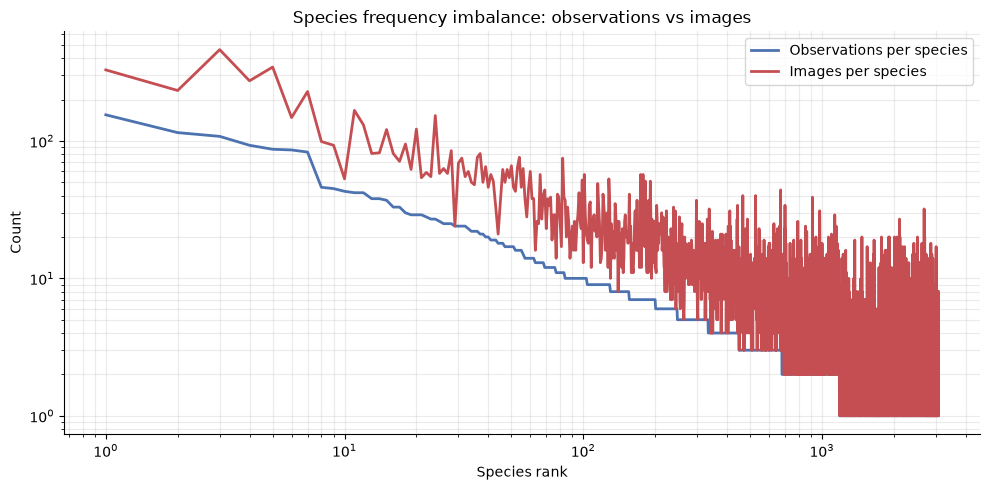

In [104]:
# Plot: image-level vs observation-level species imbalance

plot_df = species_freq.reset_index(drop=True).copy()
plot_df["species_rank"] = np.arange(1, len(plot_df) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_df["species_rank"],
    plot_df["observation_count"],
    label="Observations per species",
    color="#4C72B0",
    linewidth=2,
)

ax.plot(
    plot_df["species_rank"],
    plot_df["image_count"],
    label="Images per species",
    color="#C44E52",
    linewidth=2,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Species rank")
ax.set_ylabel("Count")
ax.set_title("Species frequency imbalance: observations vs images")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

### Top species share at image and observation level

In [105]:
# Top species share at image and observation level

top_species_share = pd.DataFrame(
    {
        "metric": [
            "Top 1 species observation share",
            "Top 1 species image share",
            "Top 5 species observation share",
            "Top 5 species image share",
            "Top 10 species observation share",
            "Top 10 species image share",
        ],
        "percent": [
            species_freq.head(1)["observation_count"].sum() / total_observations * 100,
            species_freq.head(1)["image_count"].sum() / total_images * 100,
            species_freq.head(5)["observation_count"].sum() / total_observations * 100,
            species_freq.head(5)["image_count"].sum() / total_images * 100,
            species_freq.head(10)["observation_count"].sum() / total_observations * 100,
            species_freq.head(10)["image_count"].sum() / total_images * 100,
        ],
    }
)

top_species_share

,metric,percent
0,Top 1 species observation share,1.932427
1,Top 1 species image share,1.372893
2,Top 5 species observation share,6.956739
3,Top 5 species image share,6.856118
4,Top 10 species observation share,10.734322
5,Top 10 species image share,9.451678


### Which taxonomic levels are most imbalanced?

In [106]:
# Which taxonomic levels are most imbalanced?

taxonomic_levels = [
    "class_name",
    "order_name",
    "family_name",
    "genus_name",
    "species_name",
]

imbalance_rows = []

for level in taxonomic_levels:
    if level not in animalia.columns:
        continue

    level_counts = (
        animalia.dropna(subset=[level])
        .groupby(level)
        .agg(
            observation_count=("obs_id", "nunique"),
            image_count=("photo_count", "sum"),
        )
    )

    total_level_obs = level_counts["observation_count"].sum()
    total_level_images = level_counts["image_count"].sum()

    imbalance_rows.append(
        {
            "taxonomic_level": level.replace("_name", ""),
            "unique_groups": level_counts.shape[0],
            "median_observations_per_group": level_counts["observation_count"].median(),
            "max_observations_in_one_group": level_counts["observation_count"].max(),
            "top_group_observation_share_percent": (
                level_counts["observation_count"].max() / total_level_obs * 100
            ),
            "top_5_group_observation_share_percent": (
                level_counts["observation_count"]
                .sort_values(ascending=False)
                .head(5)
                .sum()
                / total_level_obs
                * 100
            ),
            "observation_gini": gini(level_counts["observation_count"]),
            "image_gini": gini(level_counts["image_count"]),
        }
    )

taxonomic_imbalance = pd.DataFrame(imbalance_rows).sort_values(
    "observation_gini", ascending=False
)

taxonomic_imbalance

,taxonomic_level,unique_groups,median_observations_per_group,max_observations_in_one_group,top_group_observation_share_percent,top_5_group_observation_share_percent,observation_gini,image_gini
0,class,29,8.0,2807,34.223360,90.819312,0.852467,0.856143
1,order,148,6.0,977,11.900122,44.165652,0.825373,0.829292
2,family,629,3.0,393,4.781022,15.498783,0.745478,0.753498
4,species,3073,1.0,155,1.932427,6.956739,0.520664,0.608039
3,genus,71,1.0,6,5.607477,22.429907,0.280637,0.402952


# Summary

In [108]:
print(f"The number of records in the dataset is {animalia.shape[0]}")
print(f"Final Total number of columns in the dataset: {animalia.shape[1]}")
print(f"Number of unique observations in the dataset is {animalia['obs_id'].nunique()}")
print(f"Number of images in the dataset: {animalia['photo_count'].sum()}")
print(f"Photo count distribution:\n{photo_count_summary}")
print(
    f"Mean photo count per observation: {photo_dist[photo_dist['statistic'] == 'mean']['photo_count'].values[0]}"
)
print(
    f"Median photo count per observation: {photo_dist[photo_dist['statistic'] == '50%']['photo_count'].values[0]}"
)
print(
    f"Maximum photo count per observation: {photo_dist[photo_dist['statistic'] == 'max']['photo_count'].values[0]}"
)
print(
    f"Minimum photo count per observation: {photo_dist[photo_dist['statistic'] == 'min']['photo_count'].values[0]}"
)

print(f"Observation license code distribution is:\n{obs_license_distribution}")
print(f"Unsupported licenses count: {unsupported_licenses_count}")
print(
    f"Missing species label count: {animalia[animalia['scientific_name'].isna() | (animalia['scientific_name'] == '')].shape[0]}"
)
print(
    f"Missing photos count: {animalia[animalia['photo_count'].isna() | (animalia['photo_count'] == 0)].shape[0]}"
)
print(f"Duplicate observations count: {animalia.duplicated(subset=['obs_id']).sum()}")

The number of records in the dataset is 8221
Final Total number of columns in the dataset: 30
Number of unique observations in the dataset is 8221
Number of images in the dataset: 24457
Photo count distribution:
1     3077
2     1787
3+    3357
dtype: int64
Mean photo count per observation: 2.9749422211409806
Median photo count per observation: 2.0
Maximum photo count per observation: 33.0
Minimum photo count per observation: 1.0
Observation license code distribution is:
  obs_license_code  count
0         cc-by-nc   5076
1            cc-by   2506
2              cc0    375
3      cc-by-nc-nd    129
4      cc-by-nc-sa     98
5         cc-by-sa     35
6         cc-by-nd      2
Unsupported licenses count: 0
Missing species label count: 0
Missing photos count: 0
Duplicate observations count: 0


In [109]:
animalia.columns

Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'scientific_name', 'taxon_rank', 'common_name',
       'latitude', 'longitude', 'positional_accuracy', 'photo_count',
       'kingdom_name', 'phylum_name', 'class_name', 'order_name',
       'family_name', 'genus_name', 'species_name', 'subspecies_name',
       'subfamily_name', 'hybrid_name', 'complex_name', 'form_name',
       'subgenus_name', 'variety_name', 'tribe_name', 'country', 'state',
       'city'],
      dtype='str')

In [110]:
animalia.shape

(8221, 30)

# save the file

In [111]:
animalia.to_parquet("../data/interim/animalia.parquet", index=False)